In [ ]:
from brian2 import *
%matplotlib inline

WARNING    't' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value 48.2 * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    C:\Users\emiel\AppData\Local\Temp\ipykernel_23852\2455684564.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend();
 [py.warnings]


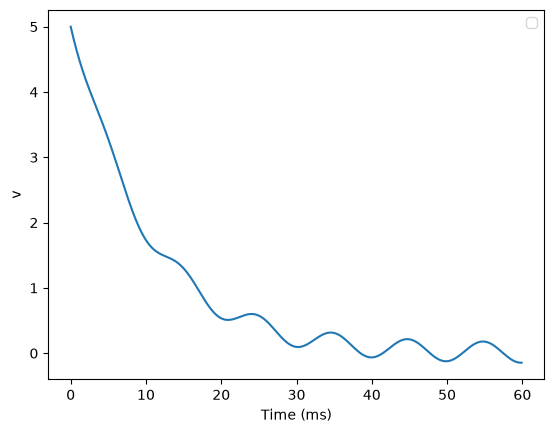

In [37]:
# Intro
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (sin(2*pi*100*Hz*t)-v)/tau : 1
'''

G = NeuronGroup(
    N=1, 
    model=eqs,
    method="euler",
)

M = StateMonitor(
    source=G, 
    variables='v', 
    record=0,
)

G.v = 5

run(60*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v')
legend();

WARNING    The object 'neurongroup_3' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\emiel\AppData\Local\Temp\ipykernel_23852\1180220158.py', line 10, in <module>
    G = NeuronGroup( [brian2.core.base.unused_brian_object]


Spike times: [16.  32.1 48.2] ms


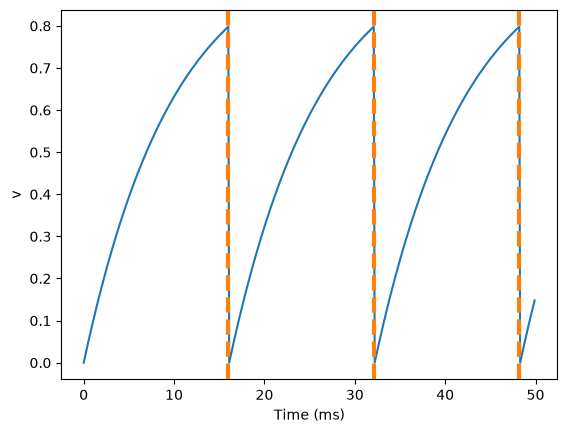

In [28]:
# Adding Spikes

start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(
    N=1,
    model=eqs,
    threshold='v>0.8',
    reset='v = 0',
    method='exact',
)

spikemon = SpikeMonitor(
    source=G,
)

statemon = StateMonitor(
    source=G,
    variables='v',
    record=0,
)

run(50*ms)

print('Spike times: %s' % spikemon.t[:])

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
xlabel('Time (ms)')
ylabel('v');

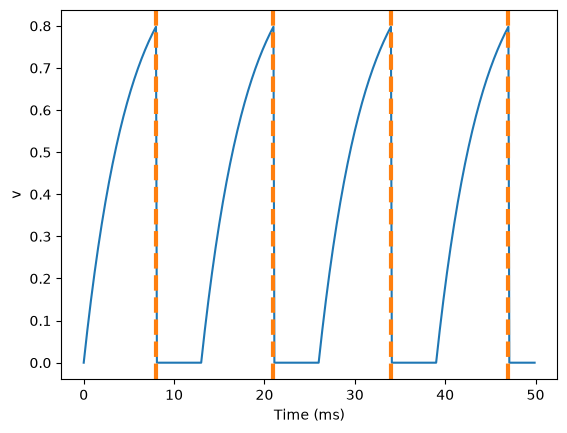

In [24]:
# Refractoriness

start_scope()

tau = 5*ms
eqs = '''
dv/dt = (1-v)/tau : 1 (unless refractory)
'''

G = NeuronGroup(
    N=1,
    model=eqs,
    threshold='v>0.8',
    reset='v = 0',
    refractory=5*ms,
    method='exact',
)

spikemon = SpikeMonitor(
    source=G,
)

statemon = StateMonitor(
    source=G,
    variables='v',
    record=0,
)

run(50*ms)

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
xlabel('Time (ms)')
ylabel('v');

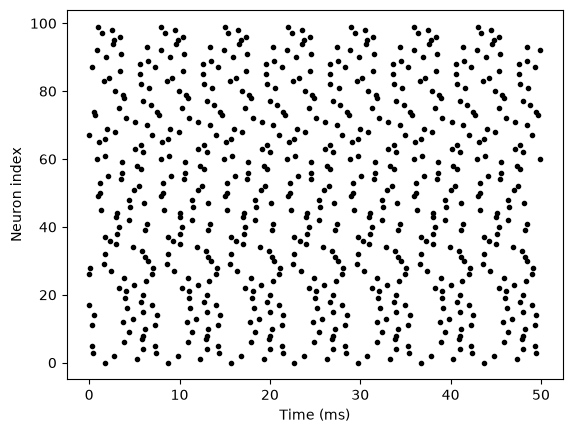

In [31]:
# Multiple Neurons

start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(
    N=N,
    model=eqs,
    threshold='v>1',
    reset='v=0',
    method='exact',
)
G.v = 'rand()'

spikemon = SpikeMonitor(G)

run(50*ms)

plot(spikemon.t/ms, spikemon.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index');

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\emiel\AppData\Local\Temp\ipykernel_23852\2542383888.py', line 9, in <module>
    G = NeuronGroup( [brian2.core.base.unused_brian_object]


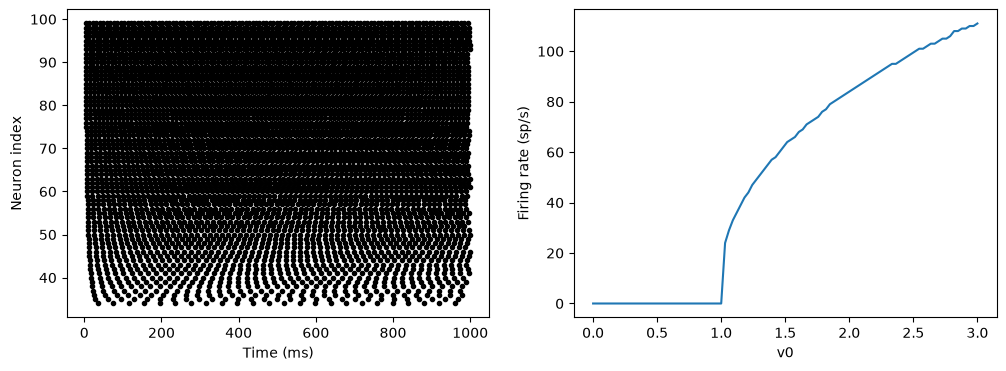

In [39]:
# More Interesting

start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms

eqs = '''
dv/dt = (v0-v)/tau : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(
    N=N,
    model=eqs,
    threshold='v>1',
    reset='v=0',
    refractory=5*ms,
    method='exact',
)

spike_monitor = SpikeMonitor(source=G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(spike_monitor.t/ms, spike_monitor.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, spike_monitor.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)');

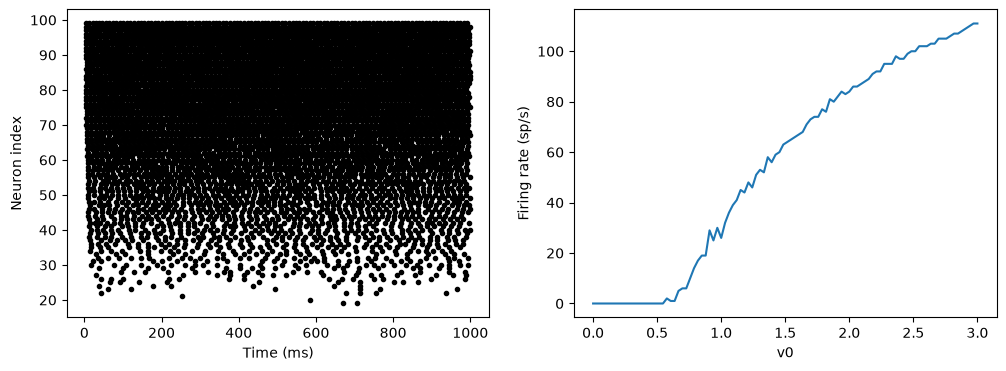

In [40]:
# Adding Stochasticity

start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms
sigma = 0.2

eqs = '''
dv/dt = (v0-v)/tau+sigma*xi*tau**-0.5 : 1 (unless refractory)
v0 : 1
'''

group = NeuronGroup(
    N=N,
    model=eqs,
    threshold='v>1',
    reset='v=0',
    refractory=5*ms,
    method='euler',
)

spike_monitor = SpikeMonitor(
    source=group,
)

group.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(spike_monitor.t/ms, spike_monitor.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(group.v0, spike_monitor.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)');

Text(0, 0.5, 'V')

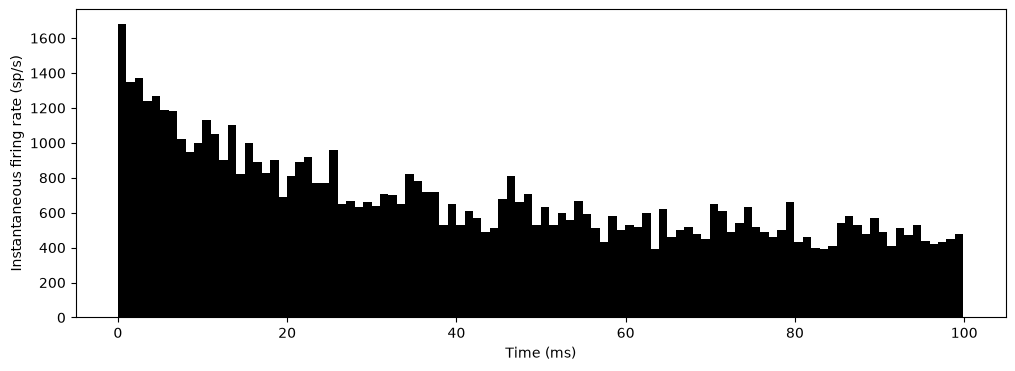

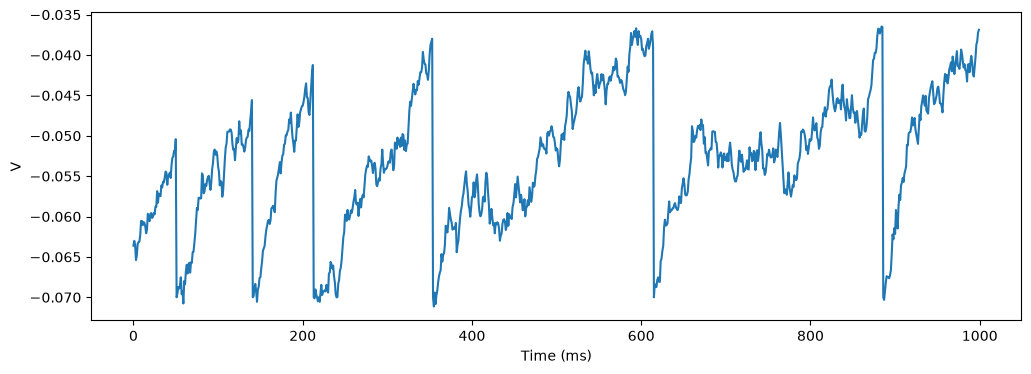

In [ ]:
# Final Practice

start_scope()

N = 1000
tau = 10*ms
vr = -70*mV
vt0 = -50*mV
delta_vt0 = 5*mV
tau_t = 100*ms
sigma = 0.5*(vt0-vr)
v_drive = 2*(vt0-vr)
duration = 100*ms

eqs = '''
dv/dt = (v_drive+vr-v)/tau + sigma*xi*tau**-0.5 : volt
dvt/dt = (vt0-vt)/tau_t : volt
'''

reset = '''
v = vr
vt += delta_vt0
'''

group = NeuronGroup(
    N=N,
    model=eqs,
    threshold='v>vt',
    reset=reset,
    refractory=5*ms,
    method='euler',
)

spikemonitor = SpikeMonitor(
    source=group,
)

statemonitor = StateMonitor(
    source=group,
    variables='v',
    record=True,
)

group.v = 'rand()*(vt0-vr)+vr'
group.vt = vt0

run(duration)

figure(figsize=(12,4))
_ = hist(
    x=spikemonitor.t/ms,
    bins=100,
    histtype='stepfilled',
    facecolor='k',
    weights=list(ones(len(spikemonitor))/(N*defaultclock.dt))
)
xlabel('Time (ms)')
ylabel('Instantaneous firing rate (sp/s)')

figure(figsize=(12,4))
plot(statemonitor.v[1])
xlabel('Time (ms)')f
ylabel('V')